# Wood cantilever beam design problem

Let's say this FBD image represents a sculpture piece for Disney where they want to show Peter Pan walking a plank. It's early in the design so the weight of the Peter Pan sculpture is uncertain (i.e., point load F value is uncertain) but we want to get an early estimate on what wood species and beam geometries (length, width, depth) can work.

<img src="../assets/cantilever_fbd.png">

In [1]:
import pymc3 as pm
import theano.tensor as tt
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Wood species and properties

| Species | ρ (kg/m³) | F_b (MPa) | F_v (MPa) | E (GPa) | E_min (MPa) |
|---|---|---|---|---|---|
| Douglas Fir-Larch | 500 | 10.3 | 1.24 | 13.1 | 4,760 |
| White Oak | 730 | 8.27 | 1.52 | 7.58 | 2,760 |
| Red Oak | 680 | 7.93 | 1.52 | 9.65 | 3,520 |
| Western Red Cedar | 360 | 6.89 | 1.07 | 7.58 | 2,760 |
| Eastern White Pine | 360 | 8.62 | 0.93 | 8.27 | 3,030 |

In [2]:
# Material properties lookup table 
# Index map: 0: Douglas Fir-Larch, 1: White Oak, 2: Red Oak, 3: Western Red Cedar, 4: Eastern White Pine
species_names = ["Douglas Fir-Larch", "White Oak", "Red Oak", "Western Red Cedar", "Eastern White Pine"]

rho_vals = np.array([500.0, 730.0, 680.0, 360.0, 360.0])       # Density (kg/m3) 
Fb_vals = np.array([10.3, 8.27, 7.93, 6.89, 8.62])             # Bending (MPa) 
Fv_vals = np.array([1.24, 1.52, 1.52, 1.07, 0.93])             # Shear (MPa) 
E_vals = np.array([13.1, 7.58, 9.65, 7.58, 8.27])              # Modulus (GPa) 
Emin_vals = np.array([4760.0, 2760.0, 3520.0, 2760.0, 3030.0]) # Min Modulus (MPa) 

## Uncertain design variables, priors, constraints

**Tip load F (sculpture weight).** Log-normal is a natural fit: weight is strictly positive, the construction-material choice (hollow FRP vs. cast resin vs. bronze) creates an asymmetric right tail, and multiplying by 9.81 preserves the shape. A reasonable prior is `ln(F_kN) ~ Normal(μ = ln(0.35), σ = 0.6)`, which centers at ~35 kg (hollow-FRP median), puts the 5–95% band at roughly 13–95 kg, and allows rare samples up to ~200 kg for solid-resin or bronze alternates. Truncate at 0.05 kN and 2.0 kN to keep the sampler well-behaved.

**Species (categorical, 5 options).** Uniform prior over `{Douglas Fir-Larch, White Oak, Red Oak, Western Red Cedar, Eastern White Pine}`. 

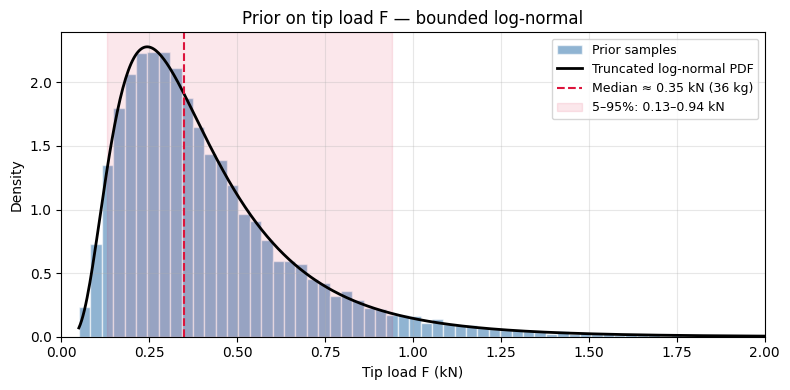

Prior summary:
  Median:      0.350 kN  (35.7 kg)
  Mean:        0.418 kN  (42.6 kg)
  5–95% band:  0.131–0.940 kN  (13.3–95.8 kg)


In [3]:
# Visualize Tip Load F prior distribution
# F_kN ~ LogNormal(mu=ln(0.35), sd=0.6) truncated to [0.05, 2.0] kN

mu, sigma = np.log(0.35), 0.6
lower, upper = 0.05, 2.0

# Sample from truncated log-normal via rejection
rng = np.random.default_rng(42)
n_target = 20000
samples = []
while len(samples) < n_target:
    batch = rng.lognormal(mean=mu, sigma=sigma, size=n_target)
    batch = batch[(batch >= lower) & (batch <= upper)]
    samples.extend(batch.tolist())
F_prior_samples = np.array(samples[:n_target])

# Analytical truncated log-normal PDF for overlay
x = np.linspace(lower, upper, 500)
pdf_raw = stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
Z = stats.lognorm.cdf(upper, s=sigma, scale=np.exp(mu)) - \
    stats.lognorm.cdf(lower, s=sigma, scale=np.exp(mu))
pdf_trunc = pdf_raw / Z

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(F_prior_samples, bins=60, density=True, alpha=0.6,
        color="steelblue", edgecolor="white", label="Prior samples")
ax.plot(x, pdf_trunc, "k-", lw=2, label="Truncated log-normal PDF")

# Reference markers: median and approximate sculpture-weight classes (kN -> kg via /9.81*1000)
median_F = np.exp(mu)
ax.axvline(median_F, color="crimson", ls="--", lw=1.5,
           label=f"Median ≈ {median_F:.2f} kN ({median_F*1000/9.81:.0f} kg)")
q05, q95 = np.quantile(F_prior_samples, [0.05, 0.95])
ax.axvspan(q05, q95, alpha=0.1, color="crimson",
           label=f"5–95%: {q05:.2f}–{q95:.2f} kN")

ax.set_xlabel("Tip load F (kN)")
ax.set_ylabel("Density")
ax.set_title("Prior on tip load F — bounded log-normal")
ax.set_xlim(0, upper)
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("Prior summary:")
print(f"  Median:      {median_F:.3f} kN  ({median_F*1000/9.81:.1f} kg)")
print(f"  Mean:        {F_prior_samples.mean():.3f} kN  ({F_prior_samples.mean()*1000/9.81:.1f} kg)")
print(f"  5–95% band:  {q05:.3f}–{q95:.3f} kN  ({q05*1000/9.81:.1f}–{q95*1000/9.81:.1f} kg)")

In [4]:
with pm.Model() as plank_design_model:
    # Priors over uncertain inputs

    # Tip load F ~ LogNormal(mu=ln(0.35), sds=0.6) truncated to [0.05, 2.0] kN 
    BoundedLogNormal = pm.Bound(pm.Lognormal, lower=0.05, upper=2.0)
    F_kN = BoundedLogNormal("F_kN", mu=np.log(0.35), sd=0.6)

    # Species selection: Categorical uniform over 5 options 
    species_idx = pm.Categorical("species_idx", p=np.ones(5) / 5.0)
    
    # Convert lookup arrays to Theano tensors and slice by the drawn categorical index
    rho_kgm3 = tt.as_tensor_variable(rho_vals)[species_idx]
    Fb_MPa = tt.as_tensor_variable(Fb_vals)[species_idx]
    Fv_MPa = tt.as_tensor_variable(Fv_vals)[species_idx]
    E_GPa = tt.as_tensor_variable(E_vals)[species_idx]
    Emin_MPa = tt.as_tensor_variable(Emin_vals)[species_idx]


**Length L:** Continuous, with a triangular prior peaked at 1.5 m and support `[1.0, 2.5]` m. Triangular (rather than uniform) gently pulls mass toward the central "dramatic but not absurd" plank lengths.

**Width w:** Continuous uniform on `[150, 300]` mm.

**Depth d:** Continuous uniform on `[25, 75]` mm

**Hard plank-aesthetic constraint d < w** enforced either in the prior (truncate the joint) or in the likelihood (reject samples that violate it). Given the ranges, d < w is almost always satisfied, but it's cleaner to enforce.

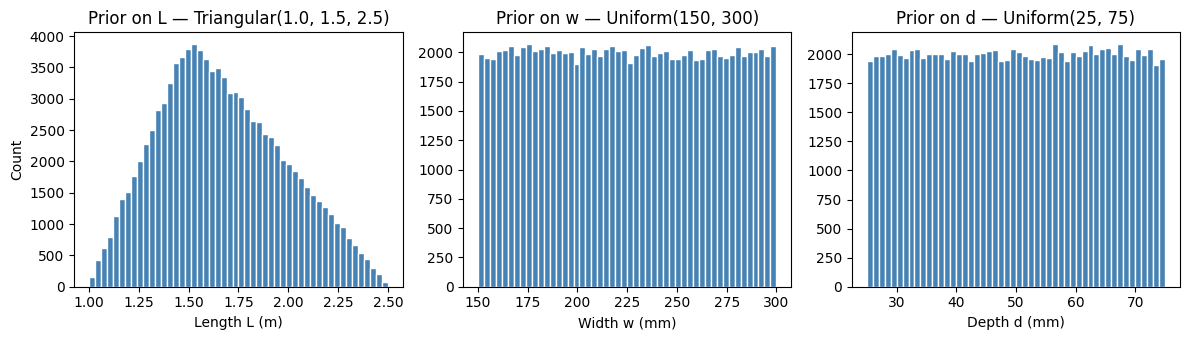

In [5]:
# Visualize L, w, d priors as univariate histograms

rng = np.random.default_rng(42)
n = 100_000

L_samples = rng.triangular(left=1.0, mode=1.5, right=2.5, size=n)
w_samples = rng.uniform(low=150.0, high=300.0, size=n)
d_samples = rng.uniform(low=25.0, high=75.0, size=n)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(L_samples, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Length L (m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Prior on L — Triangular(1.0, 1.5, 2.5)")

axes[1].hist(w_samples, bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Width w (mm)")
axes[1].set_title("Prior on w — Uniform(150, 300)")

axes[2].hist(d_samples, bins=50, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Depth d (mm)")
axes[2].set_title("Prior on d — Uniform(25, 75)")

plt.tight_layout()
plt.show()

In [6]:
with plank_design_model:      
    # Geometry priors 
    L_m = pm.Triangular("L_m", lower=1.0, c=1.5, upper=2.5)
    w_mm = pm.Uniform("w_mm", lower=150.0, upper=300.0)
    d_mm = pm.Uniform("d_mm", lower=25.0, upper=75.0)

    # Hard aesthetic constraint: d < w 
    pm.Potential("aesthetic_constraint", tt.switch(d_mm < w_mm, 0.0, -np.inf))

**NDS-based wood design** calculations (via Theano tensors) checking for:
 - Bending stress (accounting for LTB)
 - Shear stress
 - Deflection (< L/240)

In [7]:
with plank_design_model:    
    # NDS Design Model 
    # Conversions to SI Base
    L_mm = L_m * 1000.0
    F_N = F_kN * 1000.0
    E_MPa = E_GPa * 1000.0

    # Section Properties
    A_mm2 = w_mm * d_mm
    I_mm4 = (w_mm * (d_mm**3)) / 12.0
    c_mm = d_mm / 2.0
    S_mm3 = I_mm4 / c_mm

    # Loading Demands
    w_sw_Nmm = rho_kgm3 * (A_mm2 * 1e-6) * 9.81 / 1000.0
    M_max_Nmm = (F_N * L_mm) + ((w_sw_Nmm * (L_mm**2)) / 2.0)
    V_max_N = F_N + (w_sw_Nmm * L_mm)

    # Stresses and Deflection
    sigma_max_MPa = M_max_Nmm / S_mm3
    tau_max_MPa = 1.5 * V_max_N / A_mm2
    delta_total_mm = ((F_N * (L_mm**3)) / (3.0 * E_MPa * I_mm4)) + ((w_sw_Nmm * (L_mm**4)) / (8.0 * E_MPa * I_mm4))

    # NDS Capacities
    # Frozen C_F at 1.50 since depth prior bounds [25, 75] mm map to nominal depths <= 4" 
    CF = 1.50 
    Fb_star = Fb_MPa * CF

    # Lateral-Torsional Buckling Factor (CL)
    Le_mm = 1.84 * L_mm
    RB = tt.sqrt((Le_mm * d_mm) / (w_mm**2))
    FbE_MPa = (1.20 * Emin_MPa) / (RB**2)

    alpha = FbE_MPa / Fb_star
    term = (1.0 + alpha) / 1.9  # 1.9 comes from 2.0 * c where NDS sawn lumber c = 0.95
    CL = term - tt.sqrt((term**2) - (alpha / 0.95))

    # Adjusted Allowables
    Fb_prime_MPa = Fb_star * CL
    Fv_prime_MPa = Fv_MPa
    delta_allow_mm = L_mm / 240.0

    # Demand-to-Capacity Ratios 
    R_bend = pm.Deterministic("R_bend", sigma_max_MPa / Fb_prime_MPa)
    R_shear = pm.Deterministic("R_shear", tau_max_MPa / Fv_prime_MPa)
    R_defl = pm.Deterministic("R_defl", delta_total_mm / delta_allow_mm)

    # Deflection as output
    defl_delta_mm = pm.Deterministic("defl_delta_mm", delta_total_mm)

## Model outputs and Likelihood evaluation

Each MCMC sample feeds the NDS design model and produces three primary outputs:
- σ_max / F'_b — **bending demand-to-capacity ratio**
- τ_max / F'_v — **shear demand-to-capacity ratio**
- δ_total / δ_allow — **deflection demand-to-capacity ratio**

The likelihood is a feasibility indicator. Two flavors:

- **Hard:** L = 1 if all three ratios ≤ 1, else 0. Posterior is the prior restricted to the feasible set. Simple, interpretable, but rejection rate can be high when the feasible set is small.
- **Soft:** L ∝ exp(−β · max(0, ratio_max − 1)²) for some β. Allows the chain to move through infeasible regions without getting stuck; useful if the feasible set is a narrow sliver of the prior.

Start with hard and switch to soft only if acceptance collapses.

In [8]:
with plank_design_model:
    # Likelihood / Feasibility Constraints
    ratio_max = tt.max([R_bend, R_shear, R_defl])

    # Option A: Hard feasibility (Posterior is the prior restricted to feasible set L=1)
    # pm.Potential("feasibility_hard", tt.switch(ratio_max <= 1.0, 0.0, -np.inf))

    # Option B: Soft feasibility, Uncomment if the hard constraint collapses acceptance rate
    penalty = tt.maximum(0.0, ratio_max - 1.0)**2
    soft_beta = 1000.0
    pm.Potential("feasibility_soft", -soft_beta * penalty) 

## MCMC samples

In [9]:
with plank_design_model:
    trace = pm.sample(10000, tune=5000, cores=2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [d_mm, w_mm, L_m, F_kN]
>CategoricalGibbsMetropolis: [species_idx]
Sampling 2 chains, 25 divergences: 100%|██████████| 30000/30000 [00:43<00:00, 694.72draws/s]
There were 24 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7214482876692428, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 25% for some parameters.


# Results

In [10]:
pm.summary(trace, ["F_kN", "L_m", "w_mm", "d_mm", "R_bend", "R_shear", "R_defl", "defl_delta_mm"])

/home/danie/miniconda3/envs/learn-pymc/lib/python3.7/site-packages/arviz/data/io_pymc3.py:92: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  FutureWarning,


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_mean,ess_sd,ess_bulk,ess_tail,r_hat
F_kN,0.216,0.102,0.059,0.401,0.002,0.001,3382.0,3382.0,2976.0,3353.0,1.0
L_m,1.426,0.224,1.037,1.828,0.004,0.003,3032.0,3032.0,2808.0,4535.0,1.0
w_mm,240.395,40.858,167.849,299.996,0.600,0.426,4639.0,4607.0,4190.0,4853.0,1.0
d_mm,66.351,6.834,53.764,74.999,0.115,0.082,3503.0,3500.0,3465.0,5259.0,1.0
R_bend,0.167,0.045,0.082,0.250,0.001,0.000,4550.0,4550.0,4492.0,6877.0,1.0
R_shear,0.026,0.007,0.014,0.039,0.000,0.000,3885.0,3885.0,3489.0,5233.0,1.0
R_defl,0.720,0.203,0.364,1.039,0.003,0.002,5554.0,5554.0,6022.0,7331.0,1.0
defl_delta_mm,4.330,1.532,1.430,7.004,0.023,0.016,4332.0,4332.0,4269.0,6806.0,1.0


### Design variable posterior distributions

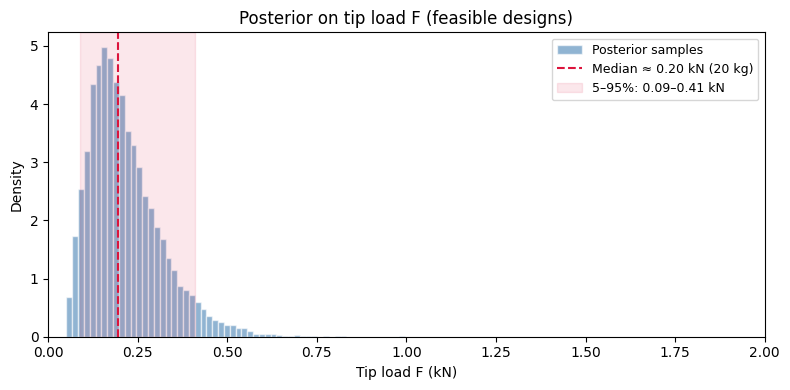

Posterior summary:
  Median:      0.195 kN  (19.9 kg)
  Mean:        0.216 kN  (22.0 kg)
  5–95% band:  0.088–0.411 kN  (9.0–41.9 kg)


In [11]:
# Visualize Tip Load F_kN posterior univariate histogram

F_posterior = trace["F_kN"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(F_posterior, bins=60, density=True, alpha=0.6,
        color="steelblue", edgecolor="white", label="Posterior samples")

median_F = np.median(F_posterior)
q05, q95 = np.quantile(F_posterior, [0.05, 0.95])
ax.axvline(median_F, color="crimson", ls="--", lw=1.5,
           label=f"Median ≈ {median_F:.2f} kN ({median_F*1000/9.81:.0f} kg)")
ax.axvspan(q05, q95, alpha=0.1, color="crimson",
           label=f"5–95%: {q05:.2f}–{q95:.2f} kN")

ax.set_xlabel("Tip load F (kN)")
ax.set_ylabel("Density")
ax.set_title("Posterior on tip load F (feasible designs)")
ax.set_xlim(0, 2.0)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("Posterior summary:")
print(f"  Median:      {median_F:.3f} kN  ({median_F*1000/9.81:.1f} kg)")
print(f"  Mean:        {F_posterior.mean():.3f} kN  ({F_posterior.mean()*1000/9.81:.1f} kg)")
print(f"  5–95% band:  {q05:.3f}–{q95:.3f} kN  ({q05*1000/9.81:.1f}–{q95*1000/9.81:.1f} kg)")

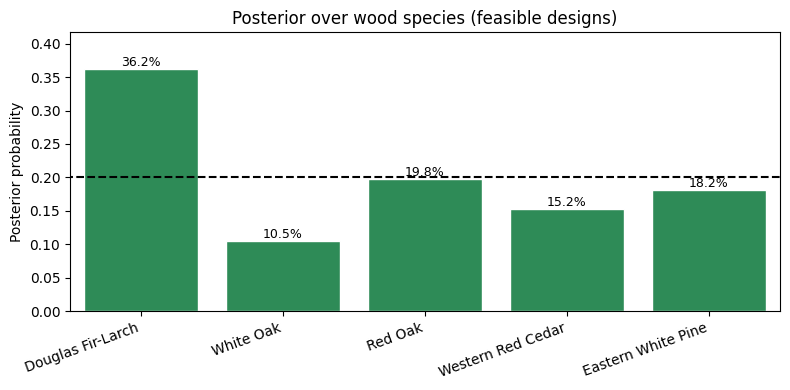

Posterior species probabilities:
  Douglas Fir-Larch      36.2%
  White Oak              10.5%
  Red Oak                19.8%
  Western Red Cedar      15.2%
  Eastern White Pine     18.2%


In [12]:
# Visualize species_idx posterior as a bar chart with named species on x-axis

species_posterior = trace["species_idx"]
counts = np.bincount(species_posterior, minlength=len(species_names))
proportions = counts / counts.sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(species_names)), proportions,
              color="seagreen", edgecolor="white")

# Annotate each bar with its proportion
for bar, p in zip(bars, proportions):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{p:.1%}", ha="center", va="bottom", fontsize=9)
    
ax.hlines(y=0.2, xmin=-1, xmax=5, linestyles='dashed',colors='black')
ax.set_xticks(range(len(species_names)))
ax.set_xticklabels(species_names, rotation=20, ha="right")
ax.set_ylabel("Posterior probability")

ax.set_title("Posterior over wood species (feasible designs)")

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(0, max(proportions) * 1.15)

plt.tight_layout()
plt.show()

print("Posterior species probabilities:")
for name, p in zip(species_names, proportions):
    print(f"  {name:<22} {p:.1%}")

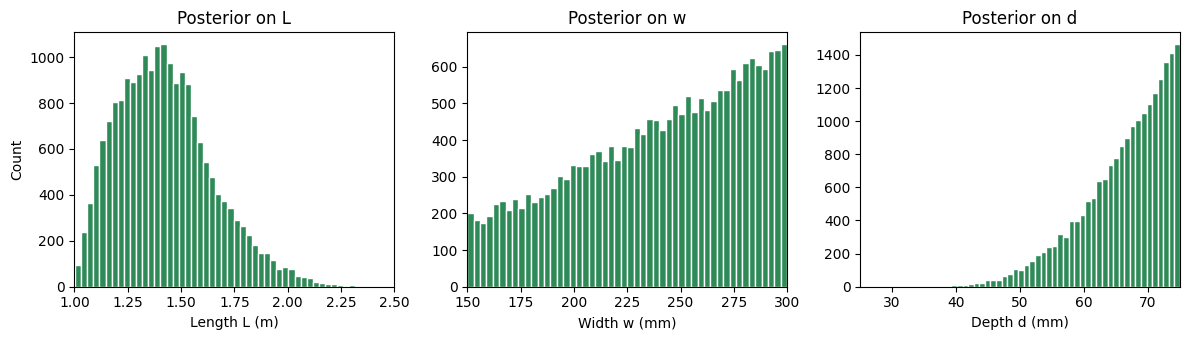

In [13]:
# Visualize L, w, d posteriors as univariate histograms

L_post = trace["L_m"]
w_post = trace["w_mm"]
d_post = trace["d_mm"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(L_post, bins=50, color="seagreen", edgecolor="white")
axes[0].set_xlim(1.0, 2.5)
axes[0].set_xlabel("Length L (m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Posterior on L")

axes[1].hist(w_post, bins=50, color="seagreen", edgecolor="white")
axes[1].set_xlim(150, 300)
axes[1].set_xlabel("Width w (mm)")
axes[1].set_title("Posterior on w")

axes[2].hist(d_post, bins=50, color="seagreen", edgecolor="white")
axes[2].set_xlim(25, 75)
axes[2].set_xlabel("Depth d (mm)")
axes[2].set_title("Posterior on d")

plt.tight_layout()
plt.show()

**Joint / bivariate plots:**
- **(w, d) scatter** colored by species: shows the geometric feasible envelope, and how the plank-aesthetic constraint d < w interacts with strength requirements.
- **(L, F) scatter**: the design envelope in span-vs-load space for each species. This is the plot a structural engineer will actually use.

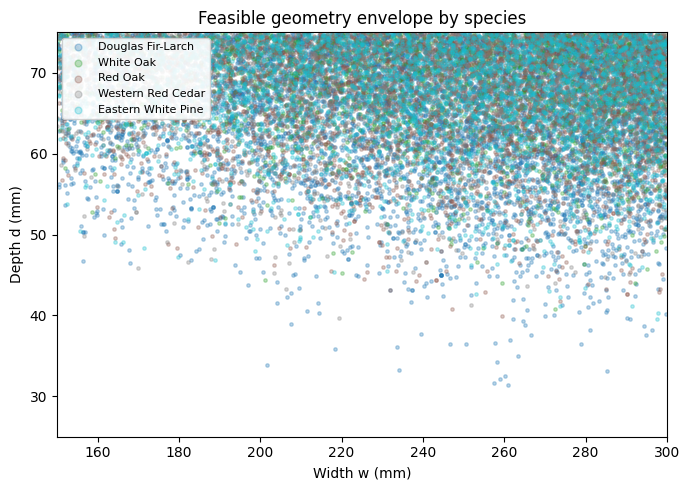

In [ ]:
# (w, d) scatter colored by species

# fig, ax = plt.subplots(figsize=(7, 5))

# colors = plt.cm.tab10(np.linspace(0, 1, len(species_names)))
# for i, name in enumerate(species_names):
#     mask = species_posterior == i
#     ax.scatter(w_post[mask], d_post[mask], s=6, alpha=0.3,
#                color=colors[i], label=name)

# ax.set_xlim(150, 300)
# ax.set_ylim(25, 75)
# ax.set_xlabel("Width w (mm)")
# ax.set_ylabel("Depth d (mm)")
# ax.set_title("Feasible geometry envelope by species")
# ax.legend(loc="upper left", fontsize=8, markerscale=2, framealpha=0.9)
# plt.tight_layout()
# plt.show()

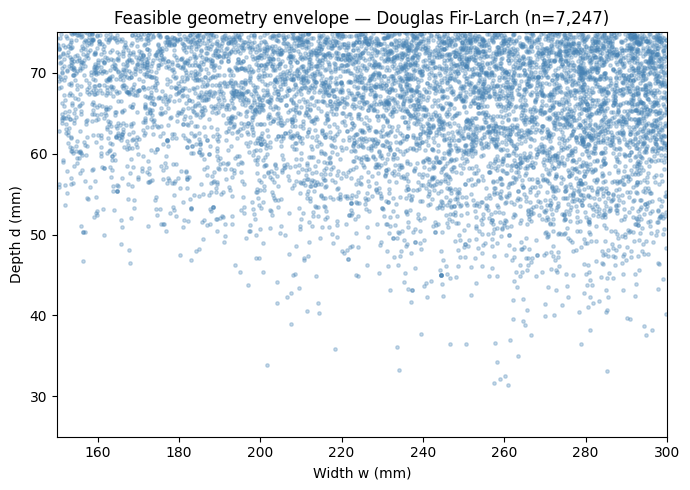

In [ ]:
# (w, d) scatter — Douglas Fir-Larch only

# dfl_idx = species_names.index("Douglas Fir-Larch")
# mask = species_posterior == dfl_idx

# fig, ax = plt.subplots(figsize=(7, 5))
# ax.scatter(w_post[mask], d_post[mask], s=6, alpha=0.3, color="steelblue")

# ax.set_xlim(150, 300)
# ax.set_ylim(25, 75)
# ax.set_xlabel("Width w (mm)")
# ax.set_ylabel("Depth d (mm)")
# ax.set_title(f"Feasible geometry envelope — Douglas Fir-Larch "
#              f"(n={mask.sum():,})")
# plt.tight_layout()
# plt.show()

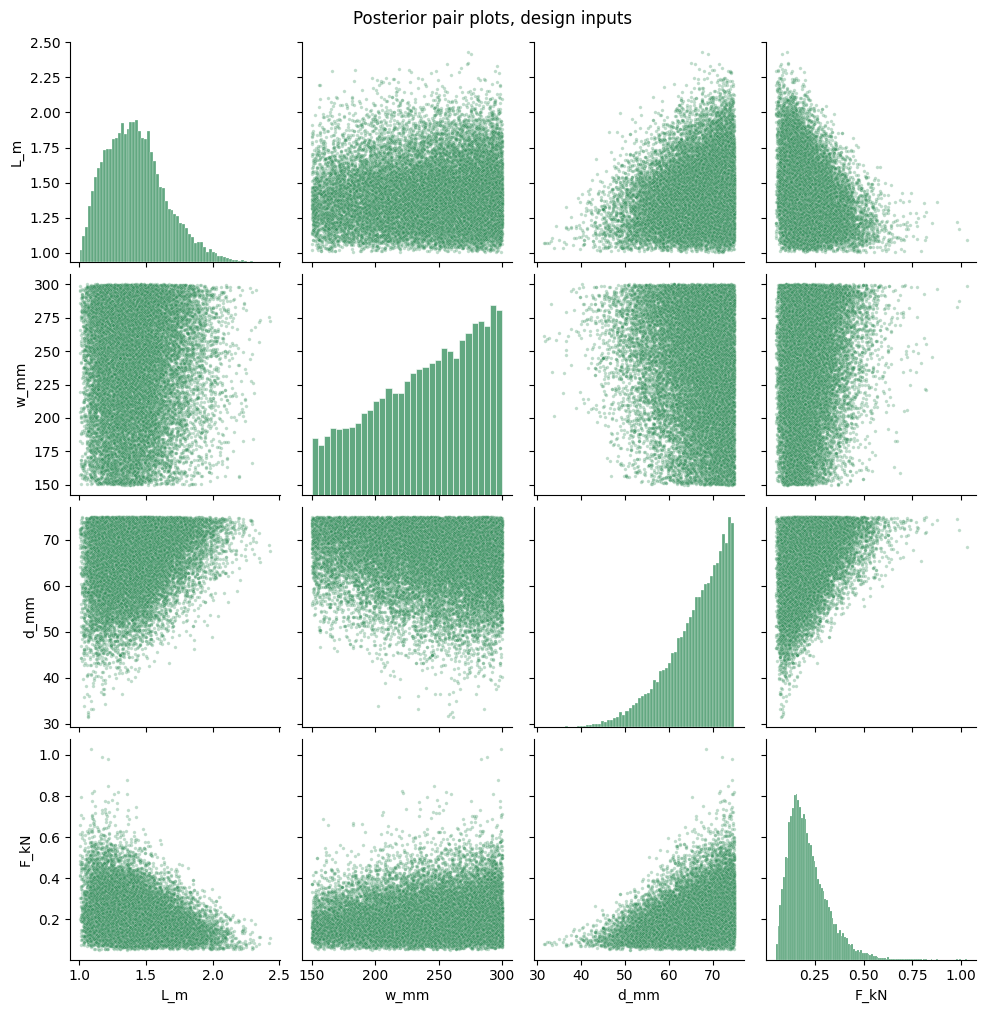

In [16]:
# posterior samples dataframe for the input variables
df_posterior = pd.DataFrame({
    "L_m": L_post,
    "w_mm": w_post,
    "d_mm": d_post,
    "F_kN": trace["F_kN"],
})

g = sns.pairplot(df_posterior, diag_kind="hist",
                 plot_kws={"s": 6, "alpha": 0.3, "color": "seagreen"},
                 diag_kws={"color": "seagreen", "edgecolor": "white"})
g.figure.suptitle("Posterior pair plots, design inputs", y=1.01)
plt.show()

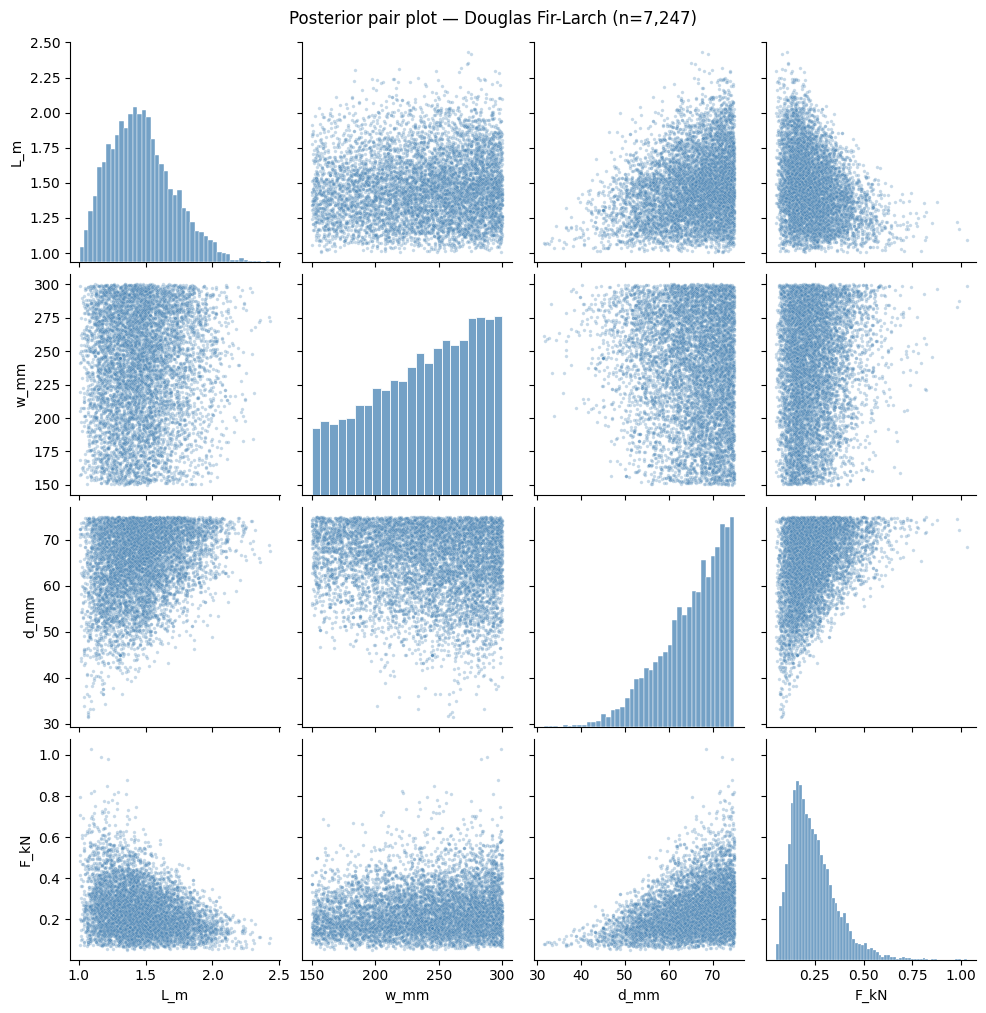

In [17]:
# Pair plot — Douglas Fir-Larch samples only

dfl_idx = species_names.index("Douglas Fir-Larch")
mask = species_posterior == dfl_idx

df_dfl = pd.DataFrame({
    "L_m": L_post[mask],
    "w_mm": w_post[mask],
    "d_mm": d_post[mask],
    "F_kN": trace["F_kN"][mask],
})

g = sns.pairplot(df_dfl, diag_kind="hist",
                 plot_kws={"s": 6, "alpha": 0.3, "color": "steelblue"},
                 diag_kws={"color": "steelblue", "edgecolor": "white"})
g.figure.suptitle(f"Posterior pair plot — Douglas Fir-Larch (n={mask.sum():,})", y=1.01)
plt.show()

### Design criterion posteriors

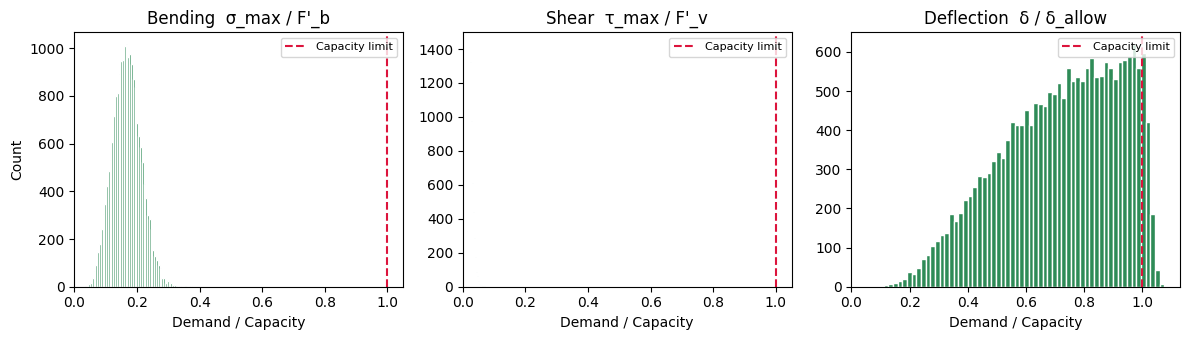

Demand/capacity ratio summaries (median [5–95%]):
  Bending     0.166  [0.094, 0.244]   (0.0% exceed 1.0)
  Shear       0.024  [0.016, 0.040]   (0.0% exceed 1.0)
  Deflection  0.743  [0.352, 1.002]   (5.3% exceed 1.0)


In [18]:
# Demand-to-capacity ratios — bending, shear, deflection

R_bend_post = trace["R_bend"]
R_shear_post = trace["R_shear"]
R_defl_post = trace["R_defl"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, data, title in zip(
    axes,
    [R_bend_post, R_shear_post, R_defl_post],
    ["Bending  σ_max / F'_b", "Shear  τ_max / F'_v", "Deflection  δ / δ_allow"],
):
    ax.hist(data, bins=60, color="seagreen", edgecolor="white")
    ax.axvline(1.0, color="crimson", ls="--", lw=1.5, label="Capacity limit")
    ax.set_xlabel("Demand / Capacity")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    # Autoscale x-axis to the data, with capacity line visible
    ax.set_xlim(0, max(data.max() * 1.05, 1.05))

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Demand/capacity ratio summaries (median [5–95%]):")
for name, data in [("Bending", R_bend_post), ("Shear", R_shear_post), ("Deflection", R_defl_post)]:
    q05, q50, q95 = np.quantile(data, [0.05, 0.50, 0.95])
    frac_over = (data > 1.0).mean()
    print(f"  {name:<11} {q50:.3f}  [{q05:.3f}, {q95:.3f}]   "
          f"({frac_over:.1%} exceed 1.0)")

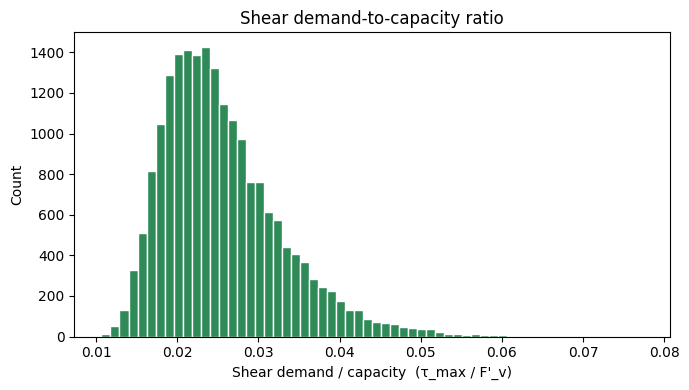

Shear ratio:  median 0.0241   range [0.0107, 0.0773]


In [21]:
# Shear ratio histogram

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(R_shear_post, bins=60, color="seagreen", edgecolor="white")
ax.set_xlabel("Shear demand / capacity  (τ_max / F'_v)")
ax.set_ylabel("Count")
ax.set_title("Shear demand-to-capacity ratio")
plt.tight_layout()
plt.show()

print(f"Shear ratio:  median {np.median(R_shear_post):.4f}   "
      f"range [{R_shear_post.min():.4f}, {R_shear_post.max():.4f}]")

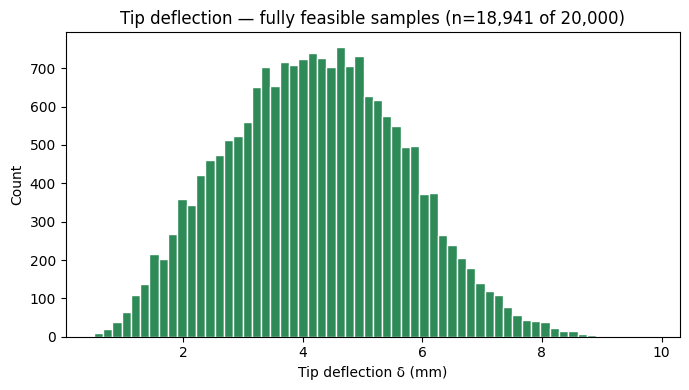

Feasible tip deflection:  median 4.20 mm   5–95% [1.84, 6.68] mm


In [20]:
# Tip deflection histogram — fully feasible samples (all three checks pass)
defl_post = trace["defl_delta_mm"]
mask_all_feasible = (R_bend_post < 1.0) & (R_shear_post < 1.0) & (R_defl_post < 1.0)
defl_feasible = defl_post[mask_all_feasible]
L_feasible = L_post[mask_all_feasible]
allow_feasible = L_feasible * 1000.0 / 240.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(defl_feasible, bins=60, color="seagreen", edgecolor="white")


ax.set_xlabel("Tip deflection δ (mm)")
ax.set_ylabel("Count")
ax.set_title(f"Tip deflection — fully feasible samples "
             f"(n={mask_all_feasible.sum():,} of {len(defl_post):,})")

plt.tight_layout()
plt.show()

print(f"Feasible tip deflection:  median {np.median(defl_feasible):.2f} mm   "
      f"5–95% [{np.quantile(defl_feasible, 0.05):.2f}, {np.quantile(defl_feasible, 0.95):.2f}] mm")